In [1]:
import arc
from arc import *
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Latex
import scipy
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e

1
channel 1 = |Rb 81s_1/2, Cs 78s_1/2> -> |Rb 80p_0.5, Cs 78p_0.5>
min defect = 6.282855162115865 MHz
c3k = 13.436400513664623
2
channel 1 = |Rb 82s_1/2, Cs 79s_1/2> -> |Rb 81p_0.5, Cs 79p_0.5>
min defect = -6.4277703480200135 MHz
c3k = 14.159207238065012
3
channel 1 = |Rb 59s_1/2, Cs 57s_1/2> -> |Rb 58p_0.5, Cs 57p_0.5>
min defect = -16.617254434440394 MHz
c3k = 3.543802615301663
4
channel 3 = |Rb 71s_1/2, Cs 69s_1/2> -> |Rb 70p_1.5, Cs 69p_0.5>
min defect = 9.307447596202802 MHz
c3k = 8.014679886495918
5
channel 3 = |Rb 72s_1/2, Cs 70s_1/2> -> |Rb 71p_1.5, Cs 70p_0.5>
min defect = -8.011277273135782 MHz
c3k = 8.508809626091129
6
channel 2 = |Rb 68s_1/2, Cs 67s_1/2> -> |Rb 67p_0.5, Cs 67p_1.5>
min defect = 2.4915156933605904 MHz
c3k = 6.500080702274083
7
channel 2 = |Rb 69s_1/2, Cs 68s_1/2> -> |Rb 68p_0.5, Cs 68p_1.5>
min defect = -10.013741360491663 MHz
c3k = 6.9167479716505404


C:\Users\tommy_y8q5nfw\AppData\Local\Temp\ipykernel_14480\882330873.py:97: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(2,1, sharex = True)


8
channel 4 = |Rb 45s_1/2, Cs 47s_1/2> -> |Rb 45p_1.5, Cs 46p_1.5>
min defect = 19.287974303366465 MHz
c3k = 1.2852938624382675
9
channel 4 = |Rb 46s_1/2, Cs 48s_1/2> -> |Rb 46p_1.5, Cs 47p_1.5>
min defect = -19.584095581320693 MHz
c3k = 1.4109464522628279
10
channel 2 = |Rb 72s_1/2, Cs 75s_1/2> -> |Rb 72p_0.5, Cs 74p_1.5>
min defect = 2.575149424746158 MHz
c3k = 9.648516855978995
11
channel 2 = |Rb 73s_1/2, Cs 76s_1/2> -> |Rb 73p_0.5, Cs 75p_1.5>
min defect = -6.244462228362467 MHz
c3k = 10.212771218990358
12
channel 3 = |Rb 48s_1/2, Cs 51s_1/2> -> |Rb 48p_1.5, Cs 50p_0.5>
min defect = -5.82021042976261 MHz
c3k = 1.6855840982807202


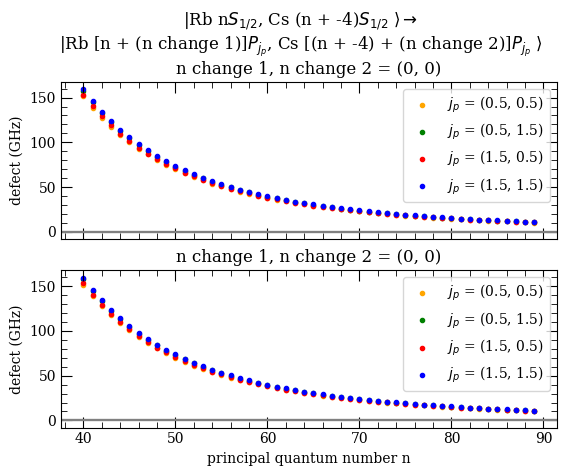

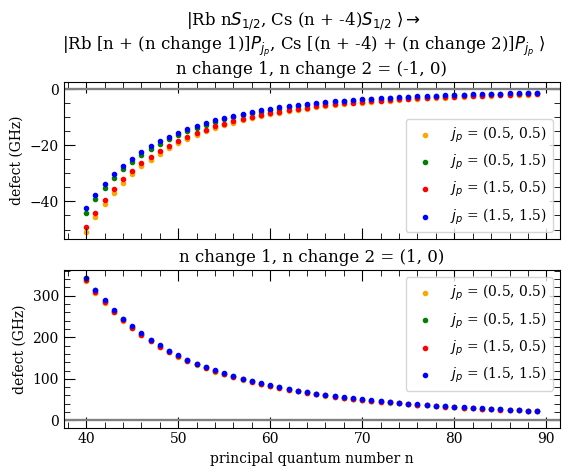

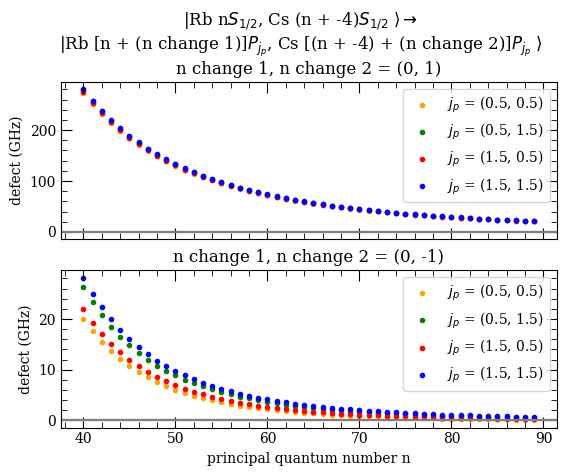

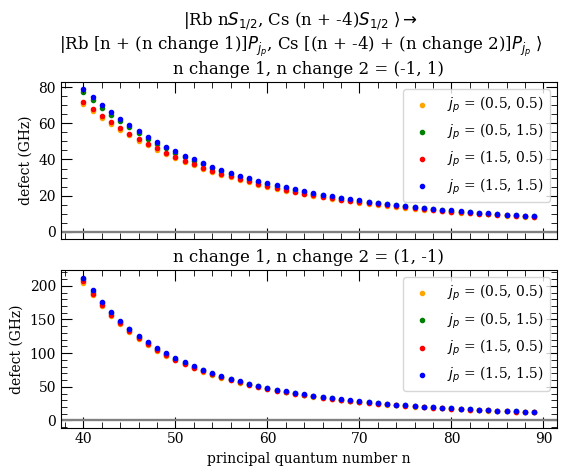

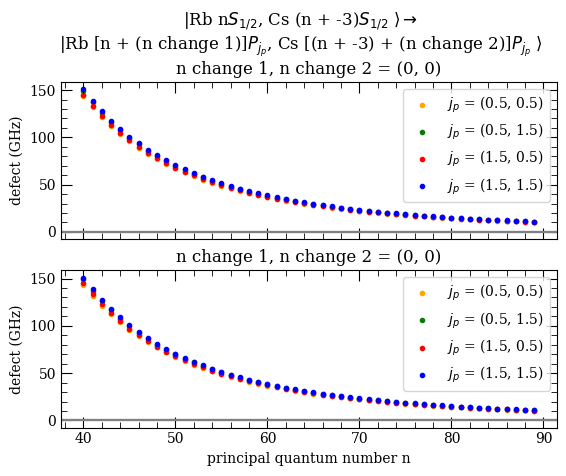

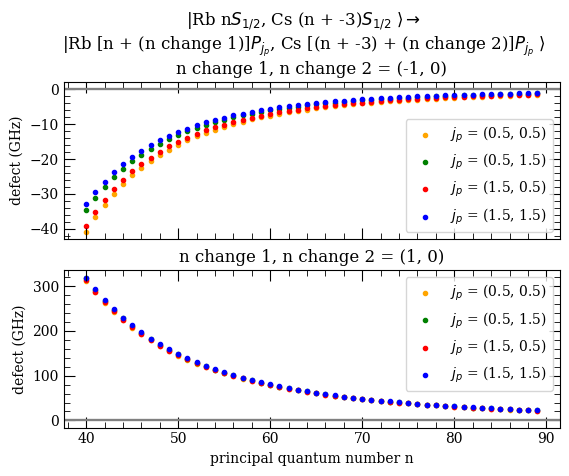

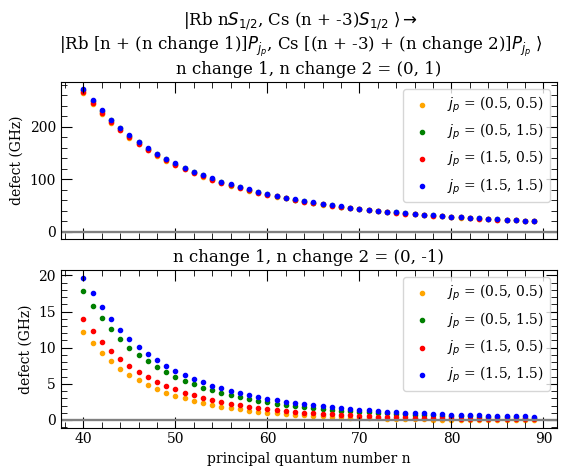

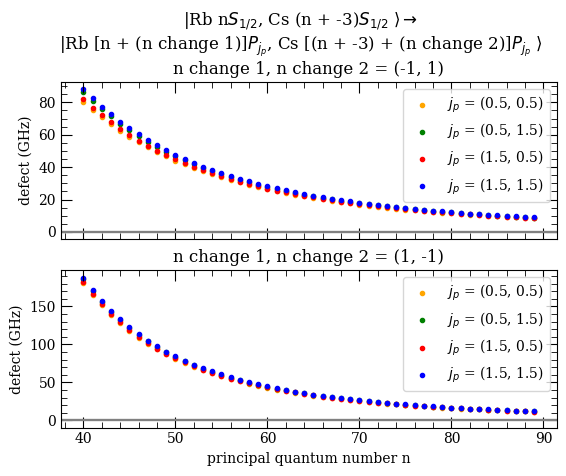

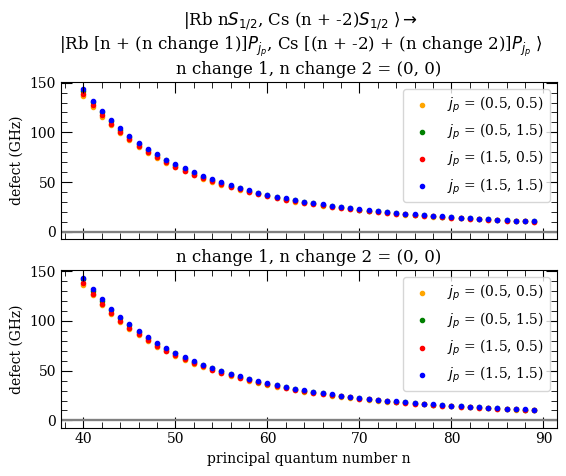

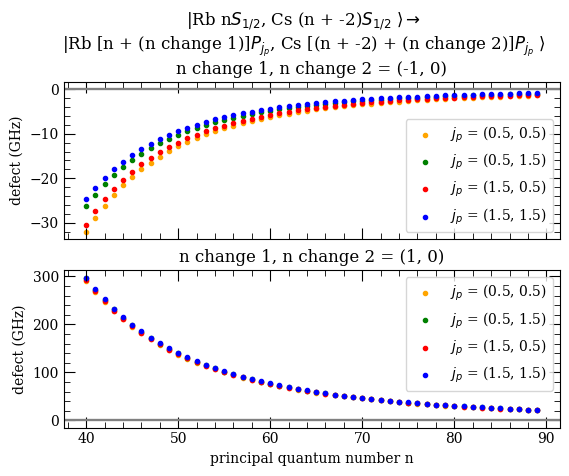

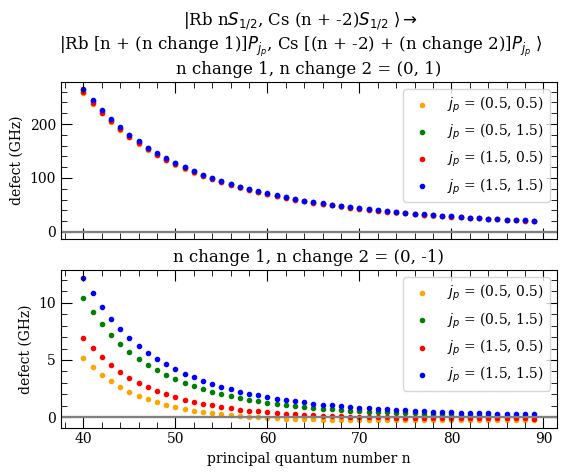

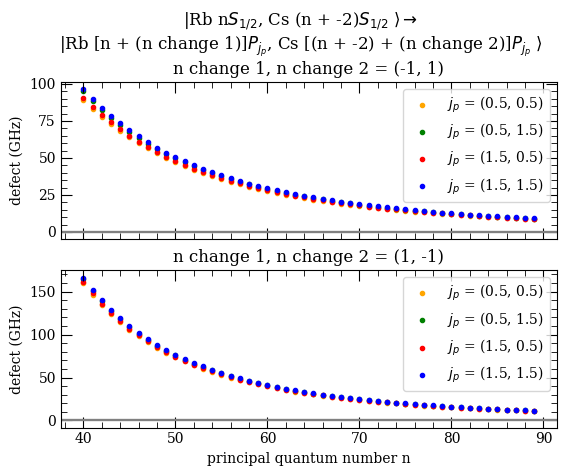

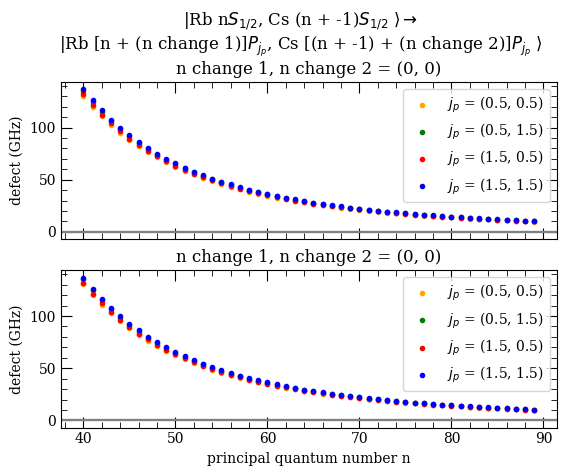

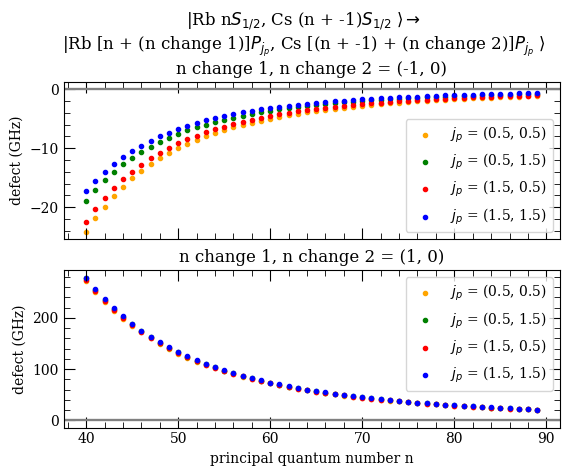

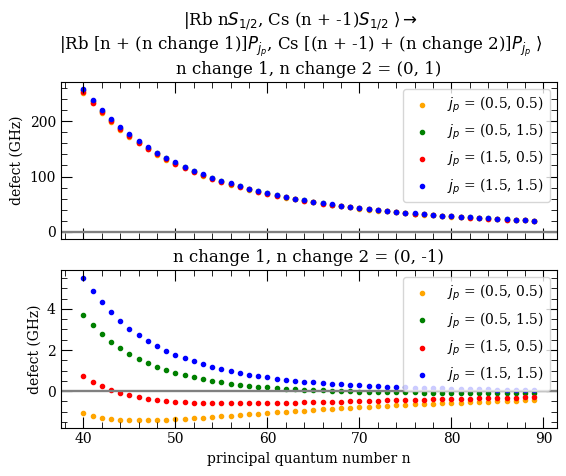

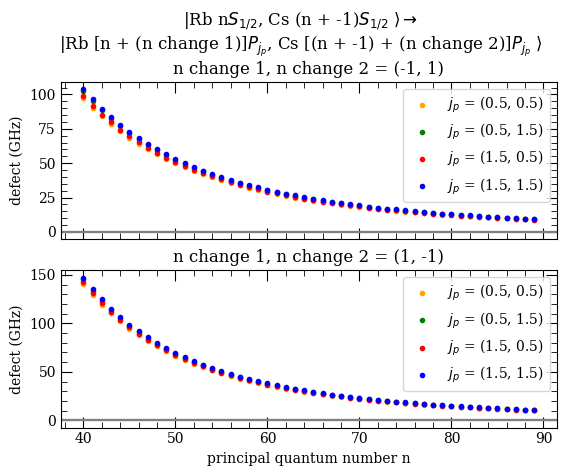

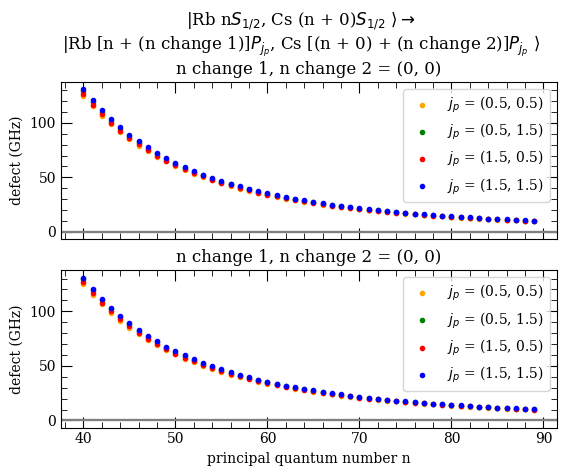

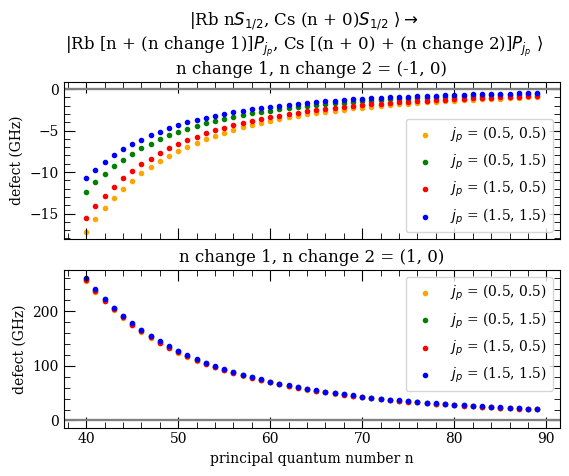

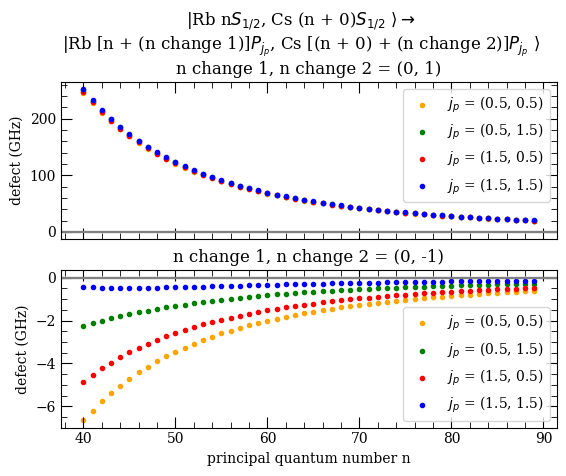

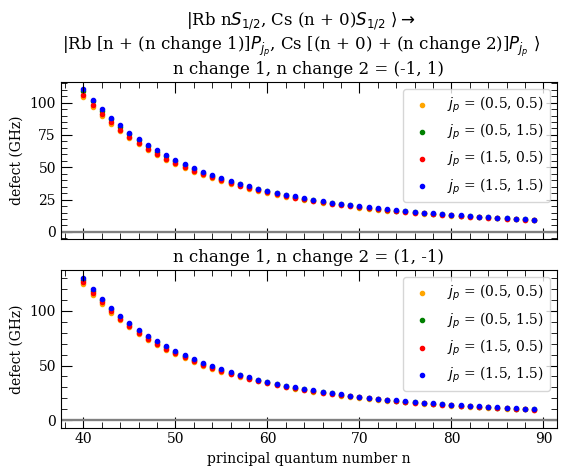

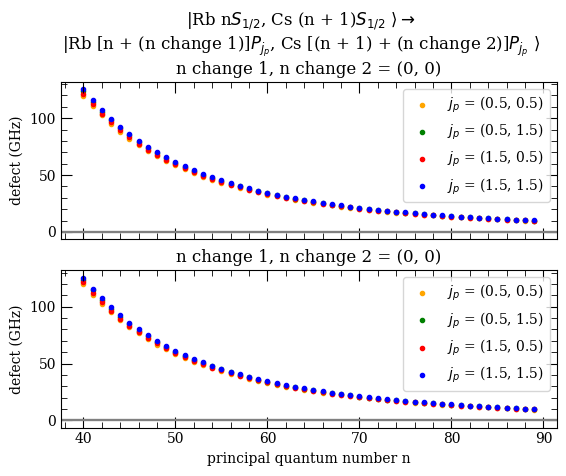

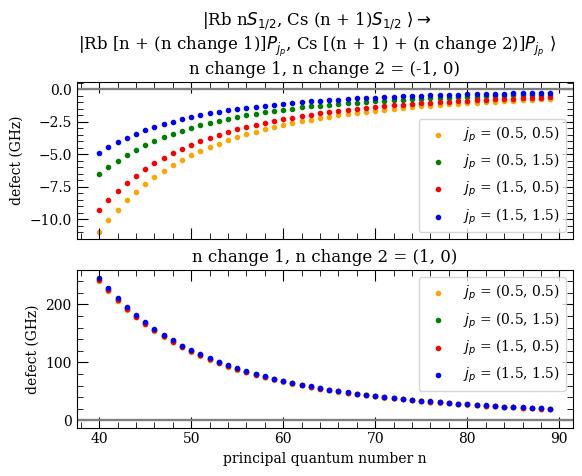

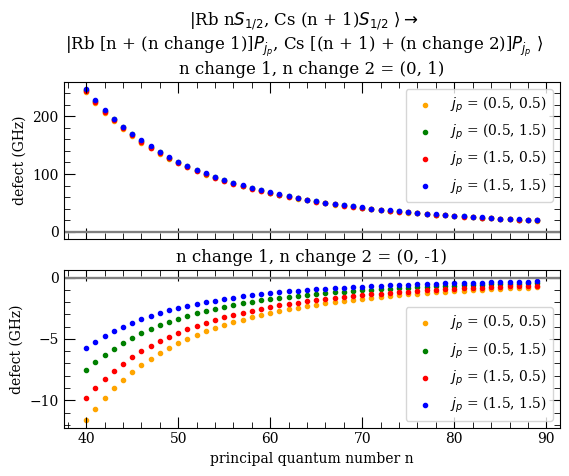

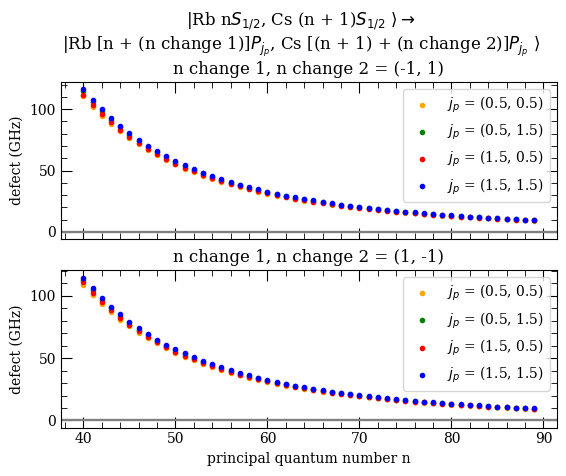

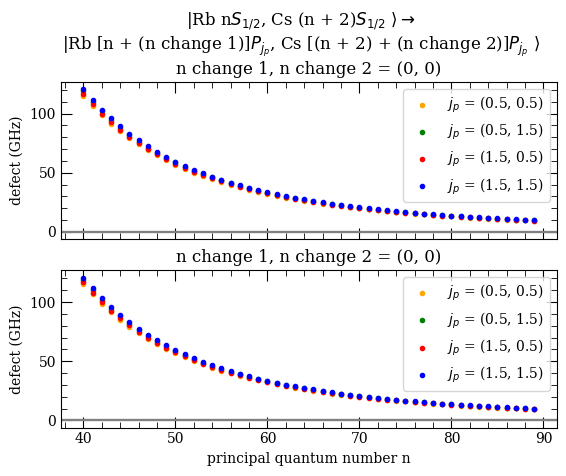

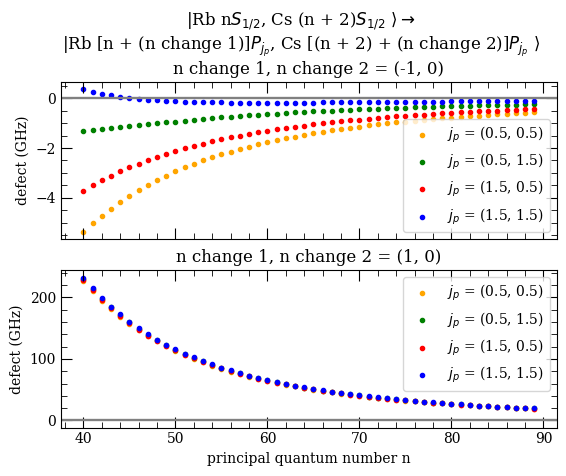

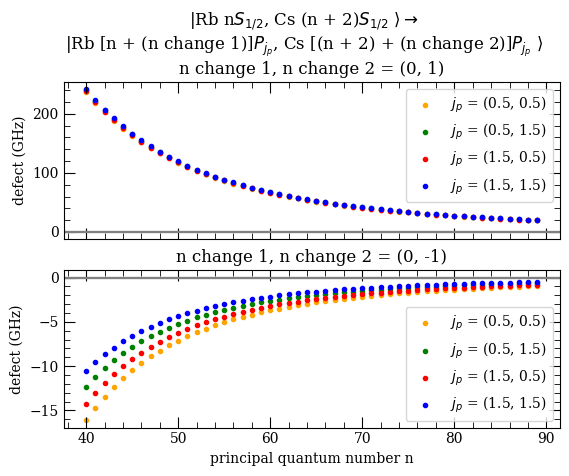

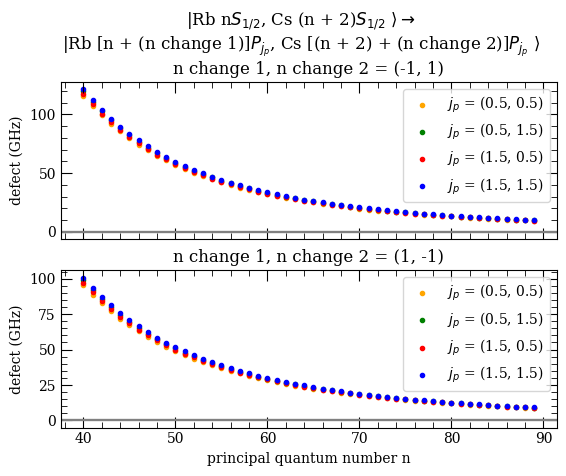

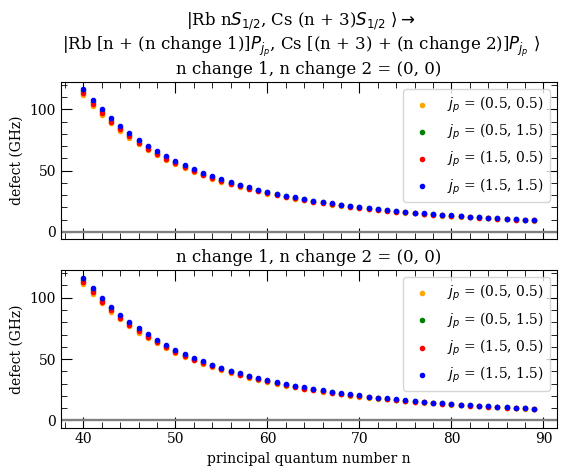

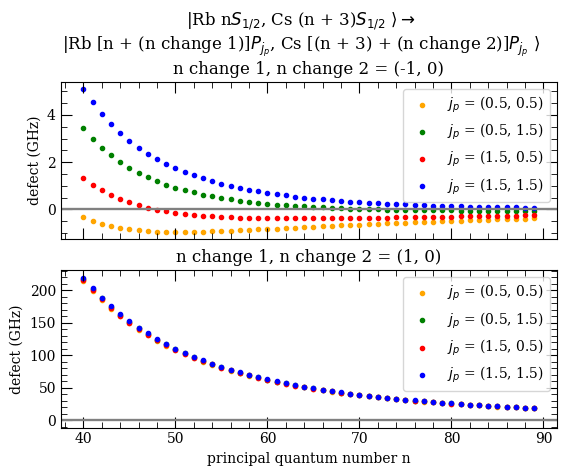

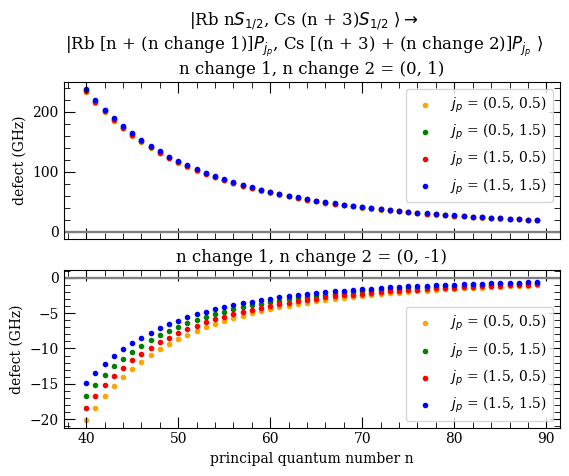

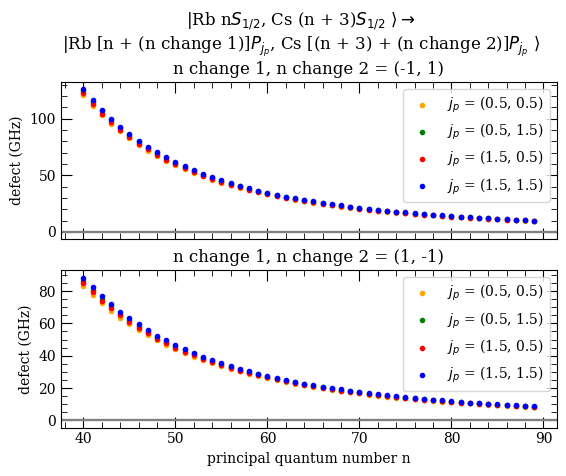

In [2]:
Rb = arc.Rubidium()
Cs = arc.Caesium()
colours = ('orange', 'green', 'red', 'blue')

difs = np.arange(-4, 4)
changes = np.arange(0, 2)

min_n = 40
max_n = 90
ns = np.arange(min_n,max_n)
jps = [(1/2,1/2), (1/2,3/2), (3/2,1/2), (3/2,3/2)]

jp_deltas = []
preferQuantumDefects = True
# C3k coefficients
c3ks = []
w=1
channels = []
num=1
for dif in difs:
    for change1 in changes:
        for change2 in changes:
            jpdelta1 = []
            jpdelta2 = []
    
            for jp in jps:    
            
                delta1 = []
                delta2 = []

                for n in ns:
                    nb = n+dif
                    # Rb lowering n
                    defect_Rb = Rb.getEnergy(n+change1, 1, jp[0], 1/2) - Rb.getEnergy(n, 0, 1/2, 1/2)
                    defect_Cs = Cs.getEnergy(nb, 0, 1/2, 1/2) - Cs.getEnergy(nb-change2, 1, jp[1], 1/2)
                    defect = defect_Rb - defect_Cs
                    delta1.append(defect*1.6e-19/h/1e9)

                    # for Cs lowering n
                    defect_Rb = Rb.getEnergy(n-change1, 1, jp[0], 1/2) - Rb.getEnergy(n, 0, 1/2, 1/2)
                    defect_Cs = Cs.getEnergy(nb, 0, 1/2, 1/2) - Cs.getEnergy(nb+change2, 1, jp[1], 1/2)
                    defect = defect_Rb - defect_Cs
                    delta2.append(defect*1.6e-19/h/1e9)
                
                jpdelta1.append(delta1)
                jpdelta2.append(delta2)

                
                min_defect1 = min(np.array(delta1), key=abs)
                min_defect2 = min(np.array(delta2), key=abs)

                defects = min_defect1, min_defect2

                for d in defects:
                    
                    for i in [-1,0,1]:
                        
                        if d == min_defect1:
                            try:
                                assoc_n = ns[delta1.index(d) + i]
                                c = [assoc_n, 0, 1/2, assoc_n+dif, 0, 1/2, assoc_n+change1, 1, jp[0], assoc_n+dif-change2, 1, jp[1], min_defect1]
                                defect = delta1[delta1.index(d)+i]
                                
                                one = True
                        
                            except IndexError:
                                continue
                            
                        if d == min_defect2:
                            try:
                                assoc_n = ns[delta2.index(d) + i]
                                c = [assoc_n, 0, 1/2, assoc_n+dif, 0, 1/2, assoc_n-change1, 1, jp[0], assoc_n+dif+change2, 1, jp[1], min_defect2]
                                defect = delta2[delta2.index(d)+i]
                                
                                one = False
                        
                            except IndexError:
                                continue
                            
                            
                        rb_matrix_element_j = Rb.getReducedMatrixElementJ(c[0], 0, .5, c[6], 1, jp[0])     
                        cs_matrix_element_j = Cs.getReducedMatrixElementJ(c[3], 0, .5, c[9], 1, jp[1])
                        
                        c3k = (a_0[0]*e) **2 / h / (4*np.pi*epsilon_0) * 1e9 * cs_matrix_element_j * rb_matrix_element_j/np.sqrt(2*jp[0]+1)/np.sqrt(2*jp[1]+1)
                        
                        c.append(c3k)
                        level_spacing= (Rb.getEnergy(assoc_n-1, 0, 1/2) - Rb.getEnergy(assoc_n, 0, 1/2))*1.6e-19/h/1e9

                        if abs(defect) < .0005 * abs(level_spacing) and abs(c3k) > 1:
                            
                            print(num)
                            num+=1
                            print(f'channel {jps.index(jp)+1} = |Rb {c[0]}s_1/2, Cs {c[3]}s_1/2> -> |Rb {c[6]}p_{c[8]}, Cs {c[9]}p_{c[11]}>')
                            print(f'min defect = {defect*1e3} MHz')
                            print(f'c3k = {c3k}')
                            channels.append(c)
            fig, axs = plt.subplots(2,1, sharex = True)
            plt.xlabel('principal quantum number n')
            for data1 in range(4):
                axs[0].scatter(ns, jpdelta1[data1], marker='.', color = colours[data1], label = r'$j_p$ = ' + str(jps[data1]))
                axs[0].set_ylabel('defect (GHz)')
                axs[0].axhline(0, color='grey')
                axs[0].set_title(f'n change 1, n change 2 = ({-change2}, {change1})')
                axs[0].legend()
            for data2 in range(4):
                axs[1].scatter(ns, jpdelta2[data2], marker='.', color = colours[data2], label = r'$j_p$ = ' + str(jps[data2]))
                axs[1].set_title(f'n change 1, n change 2 = ({change2}, {-change1})')
                axs[1].axhline(0, color='grey')
                axs[1].set_ylabel('defect (GHz)')
                axs[1].legend()
            fig.suptitle(fr'|Rb n$S_{{1/2}}$, Cs (n + {dif})$S_{{1/2}}$ $\rangle \rightarrow$' + '\n' +
                          fr'|Rb [n + (n change 1)]$P_{{j_p}}$, Cs [(n + {dif}) + (n change 2)]$P_{{j_p}}$ $\rangle$')
            fig.subplots_adjust(top=0.83)
            plt.savefig(f'C:\\Users\\tommy_y8q5nfw\\OneDrive - Durham University\\level 4 Project\\Figures\\CsCs defects\\dif={dif}, changes={change1}, {change2}')
            # plt.show()
            # print(change1, change2)

[np.int64(72), 0, 0.5, np.int64(70), 0, 0.5, np.int64(71), 1, 1.5, np.int64(70), 1, 0.5, np.float64(-0.008011277273135782), np.float64(8.508809626091129)]
-0.008011277273135782
                  ARPACK can only find up to dimension-1 eigenvectors, where                dimension is matrix dimension.



Diagonalizing interaction matrix...

99%[[71, 1, 1.5, 70, 1, 0.5, np.float64(-0.008022175784591003)], [72, 0, 0.5, 70, 0, 0.5, np.float64(0.0)]]
 Now we are plotting...
energy range = 0.009613532727762938
Data points to fit =  600
Rvdw =   13.830882771339107  mu m
offset =  -1.0000000056851207e-08 
 scale =  -10.608339803026567
errors =  [2.80020089e-18 2.11866706e-14 3.60855786e-14]


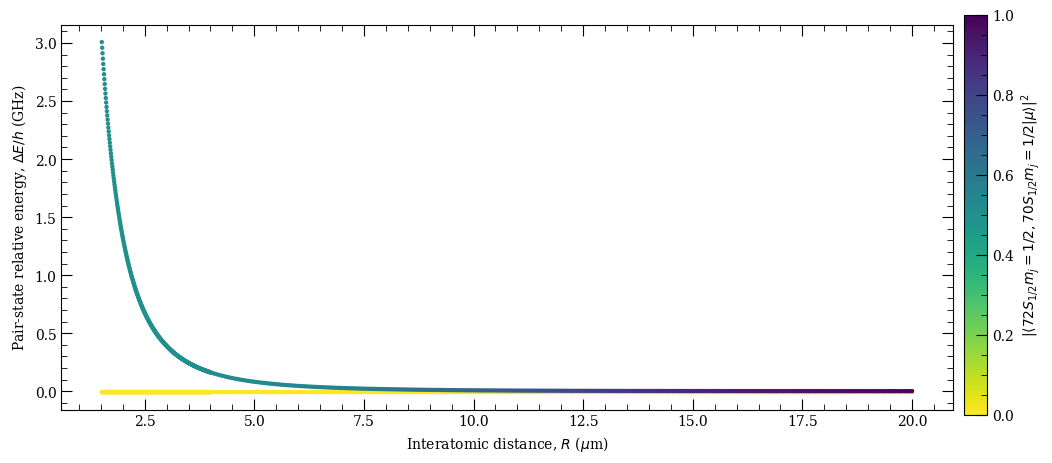

<Figure size 640x480 with 0 Axes>

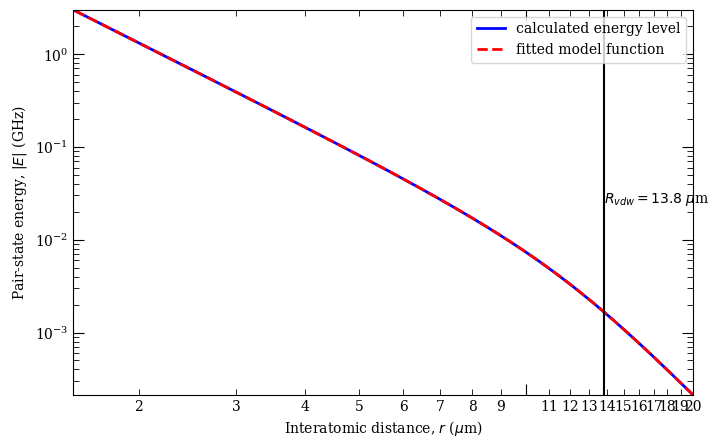

c3 =  10.38921651703678  GHz /R^3 (mu m)^3
offset =  -0.003099468309989893


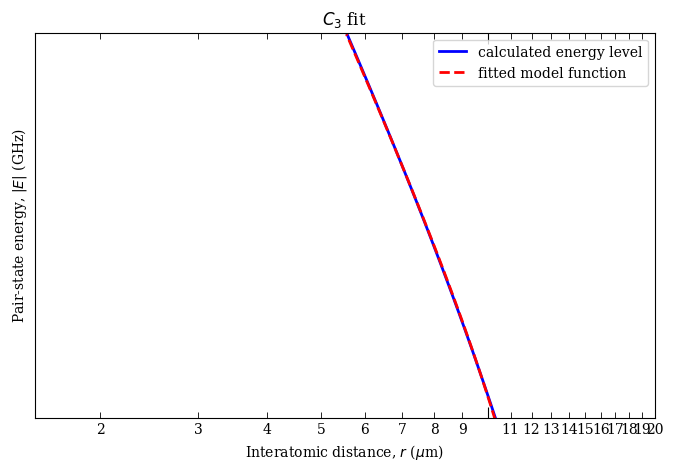

2


Diagonalizing interaction matrix...

99%[[69, 0, 0.5, 69, 3, 2.5, np.float64(0.08681889376740444)], [69, 0, 0.5, 69, 3, 3.5, np.float64(0.08681889376740444)], [69, 1, 0.5, 72, 1, 0.5, np.float64(-0.4014008692752003)], [69, 1, 0.5, 72, 1, 1.5, np.float64(0.2664466926463726)], [69, 1, 1.5, 72, 1, 0.5, np.float64(-0.10385579164454473)], [69, 1, 1.5, 72, 1, 1.5, np.float64(0.5639917702768185)], [69, 0, 0.5, 73, 0, 0.5, np.float64(-0.23484229612650753)], [70, 3, 2.5, 69, 0, 0.5, np.float64(-1.5493957544532437)], [70, 3, 3.5, 69, 0, 0.5, np.float64(-1.5498621419379175)], [70, 1, 0.5, 71, 1, 0.5, np.float64(0.6173793415378365)], [70, 1, 0.5, 71, 1, 1.5, np.float64(1.3153836204809068)], [70, 1, 1.5, 71, 1, 0.5, np.float64(0.9018675418567138)], [70, 1, 1.5, 71, 1, 1.5, np.float64(1.5998718207997842)], [71, 1, 0.5, 70, 1, 0.5, np.float64(-0.2802064005413563)], [71, 1, 0.5, 70, 1, 1.5, np.float64(0.4497978883719062)], [71, 1, 1.5, 70, 1, 0.5, np.float64(-0.008022175784591003)], [71, 1, 1.5, 7

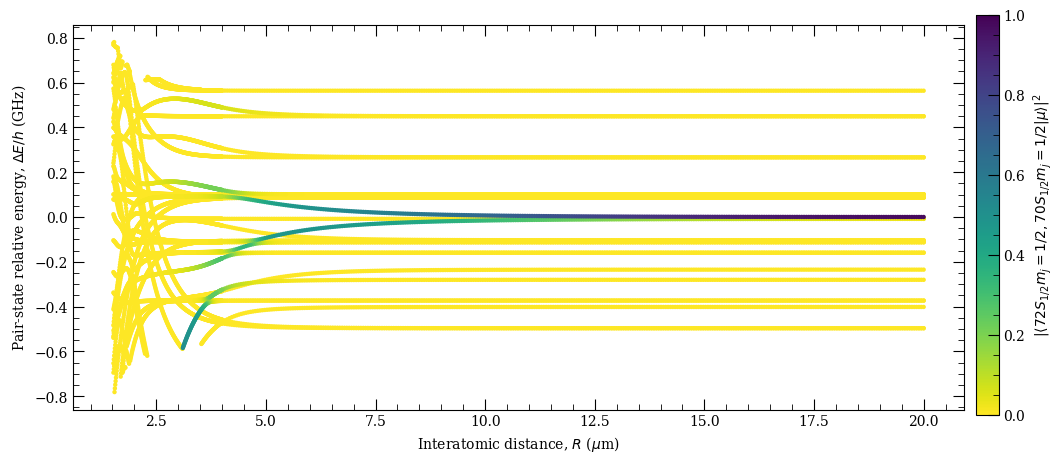

<Figure size 640x480 with 0 Axes>

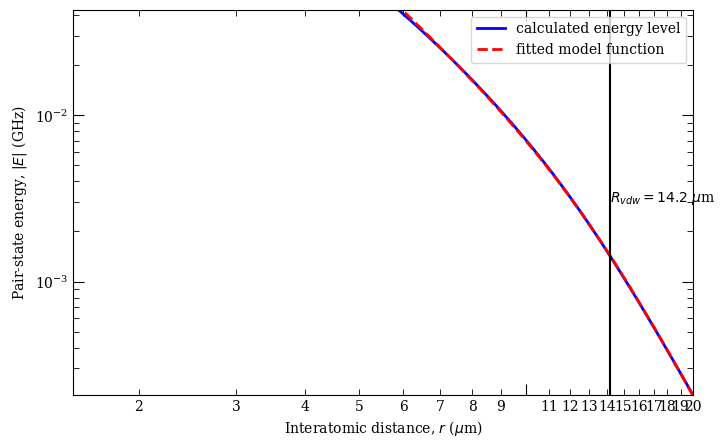

c3 =  9.484868328487575  GHz /R^3 (mu m)^3
offset =  -0.0023617957612513418


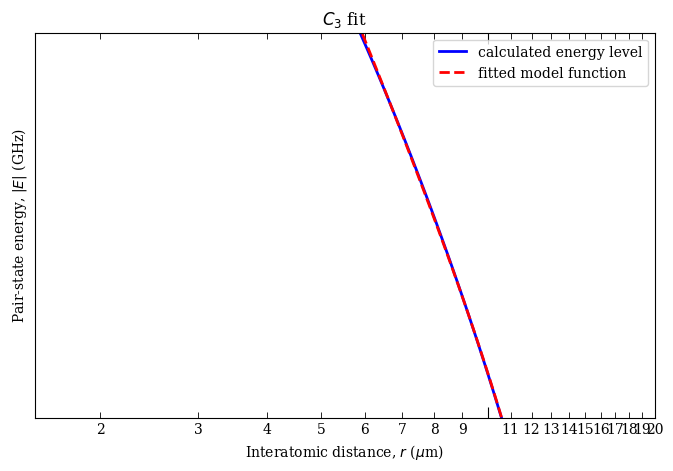

30


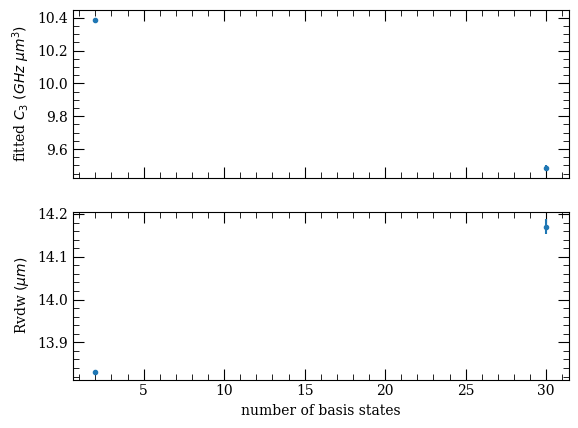

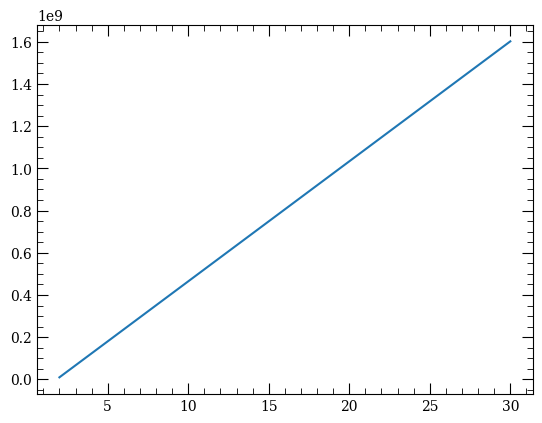

In [3]:

channel=5
c = channels[channel-1]
print(c)

import os
newpath = fr'C:\\Users\\tommy_y8q5nfw\\OneDrive - Durham University\\level 4 Project\\Figures\\Fitting C3\\RbCs\\{c[0]}s-{c[3]}s' 
if not os.path.exists(newpath):
    os.makedirs(newpath)

no_states = []
c3_fits=[]
c3_errors=[]
rvdws=[]
rvdw_errors=[]

energy_deltas = np.linspace(1.2*abs(c[12]*1e9), 2e2 * abs(c[12]*1e9), 2)
print(c[12])
for energy in energy_deltas:    
    
    pair = PairStateInteractions(Rubidium(), c[0], 0, 1/2, c[3], 0, 1/2, 1/2, 1/2, interactionsUpTo=2, s2=1/2, atom2=Caesium())

    pair.defineBasis(0, 0, 3, 3, energy, progressOutput=False)
    

    rvdw = pair.getLeRoyRadius()

    r = np.append(np.linspace(rvdw, 4, 300), np.linspace(4.01, 20, 300))

    nEig = len(pair.channel)
    pair.diagonalise(r, nEig, progressOutput=True)
    print(pair.channel)
    pair.plotLevelDiagram()
    print('energy range = ' + str(energy*1e-9))

    plt.savefig(newpath + f'\\level diagram {len(pair.channel)}channels')

    plt.figure()
    rvdw2 = pair.getVdwFromLevelDiagram(
        .500000, 30.000000, minStateContribution=0.2, showPlot=True
    )

    rvdw2[2].savefig(newpath + f'\\rvdw_fit {len(pair.channel)}channels')
    
    c3 = pair.getC3fromLevelDiagram(
        rvdw2[0]*.4, rvdw2[0] * 0.75, showPlot=True, minStateContribution=0.2
    )
    
    c3[2].savefig(newpath + f'\\c3_fit {len(pair.channel)}channels')
    
    print(len(pair.channel))
    
    no_states.append(len(pair.channel))
    c3_fits.append(c3[0])
    c3_errors.append(c3[1])

    rvdws.append(rvdw2[0])
    rvdw_errors.append(rvdw2[1])
fig, ax = plt.subplots(2, 1, sharex= True)
ax[0].errorbar(no_states, c3_fits, yerr = c3_errors, fmt='.')
ax[0].set_ylabel(r'fitted $C_3$ $(GHz$ $\mu m^3 )$')
plt.xlabel('number of eigenstates')
# plt.axhline(y=c3ks[channel-1] * np.sqrt(c[8]), color='red')

ax[1].errorbar(no_states, rvdws, yerr=rvdw_errors, fmt='.')
plt.ylabel(r'Rvdw $(\mu m)$')
plt.xlabel('number of basis states')
# plt.axhline(y=(c3k*1e9*np.sqrt(c[8])/abs(c[7])*1e3)**(1/3), color='red')


plt.savefig(newpath + '\\fitted c3,rvdw')
plt.show()

plt.figure()
plt.plot(no_states, energy_deltas)
plt.show()

In [ ]:
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=True)

Rb = pi.KetAtom('Rb', n=c['n1_0'], l=0, j=c['j1_0'], m=1/2)
energy = Rb.get_energy('GHz')
print(energy)

RbBasis = pi.BasisAtom('Rb', n=(Rb.n - 3, Rb.n + 3),
                       m = (Rb.m, Rb.m),
                       energy = (energy-4, energy + 4),
                       energy_unit='GHz')

systems = [
    pi.SystemAtom(RbBasis)
    .set_ion_distance_vector([0,0,d], 'um')
    for d in r
]

pi.diagonalize(systems,
               energy_range=(energy - 0.34, energy -0.04),
               energy_range_unit='GHz')